<a href="https://colab.research.google.com/github/ZackyRioOrlando/Praktikum-Pembelajaran-Mesin-/blob/main/JS04/JS04_TUGAS_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tugas

1. Identifikasi variabel-variabel yang akan digunakan sebagai variabel bebas (fitur) dan variabel target (biaya medis personal).

2. Bagi dataset menjadi data latih (train) dan data uji (test) dengan proporsi yang sesuai.

3. Lakukan feature scaling jika diperlukan.

4. Buat model multiple linear regression menggunakan Scikit-Learn.

5. Latih model pada data latih dan lakukan prediksi pada data uji.

6. Evaluasi model dengan menghitung metrik seperti R-squared, MSE, dan MAE. Tampilkan hasil evaluasi.

7. Ulagi langkah 4 dengan menggunakan model SVR. Anda dapat bereksperimen dengan dengan melakukan hyperparameter tunning.

Langkah 1: Import Library

In [72]:
	# import package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import TransformedTargetRegressor

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Langkah 2: Baca Data

In [1]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [4]:
	# baca data dari file CSV
	data = pd.read_csv('insurance.csv')

Langkah 3: Melihat informasi dataset

In [12]:
	# melihat beberapa data awal
	data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
# informasi tentang data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [16]:
	# mengecek ukuran data
	data.shape

(1338, 7)

In [18]:
# deskripsi data
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Langkah 4: Menentukan fitur dan target

In [19]:
X = data.drop("charges", axis=1)
y = data["charges"]

Fitur: age, sex, bmi, children, smoker,region

Target:
charges

Langkah 5: Visualisasi data

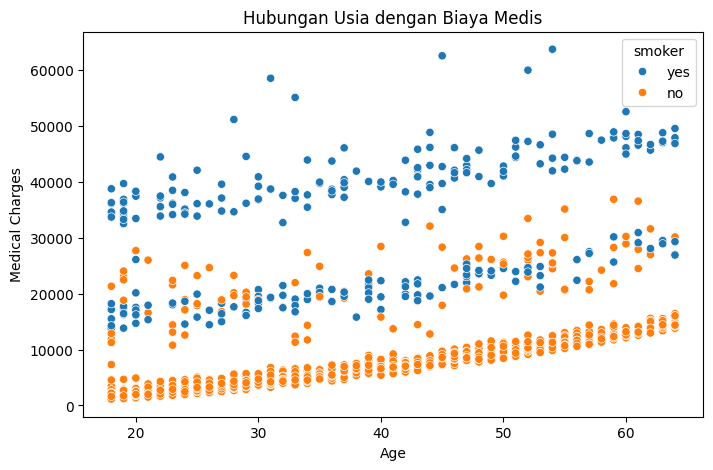

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="age",
    y="charges",
    hue="smoker"
)

plt.title("Hubungan Usia dengan Biaya Medis")
plt.xlabel("Age")
plt.ylabel("Medical Charges")
plt.show()

Dari grafik tersebut, saya dapat melihat bahwa biaya medis cenderung memiliki hubungan dengan usia dan status merokok.

Langkah 6: Melakukan encoding untuk variabel kategorikal

In [25]:
kategorikal_fitur = ["sex", "smoker", "region"]
numerik_fitur = ["age", "bmi", "children"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerik_fitur),
        ("cat", OneHotEncoder(handle_unknown="ignore"), kategorikal_fitur)
    ]
)

Langkah 7: Membagi data train dan data test

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing :", X_test.shape[0])

Jumlah data training: 1070
Jumlah data testing : 268


Langkah 8: Model Multiple Linear Regression

In [41]:
from sklearn.pipeline import Pipeline

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)
y_prediksi_linear = linear_model.predict(X_test)

Langkah 9: Evaluasi Linear Regression

In [42]:
r2_linear = r2_score(y_test, y_prediksi_linear)
mse_linear = mean_squared_error(y_test, y_prediksi_linear)
mae_linear = mean_absolute_error(y_test, y_prediksi_linear)

print("Model Multiple Linear Regression")
print("R-squared :", r2_linear)
print("MSE       :", mse_linear)
print("MAE       :", mae_linear)

Model Multiple Linear Regression
R-squared : 0.7835929767120722
MSE       : 33596915.851361476
MAE       : 4181.194473753652


Langkah 10: Visualisasi hasil Linear Regression

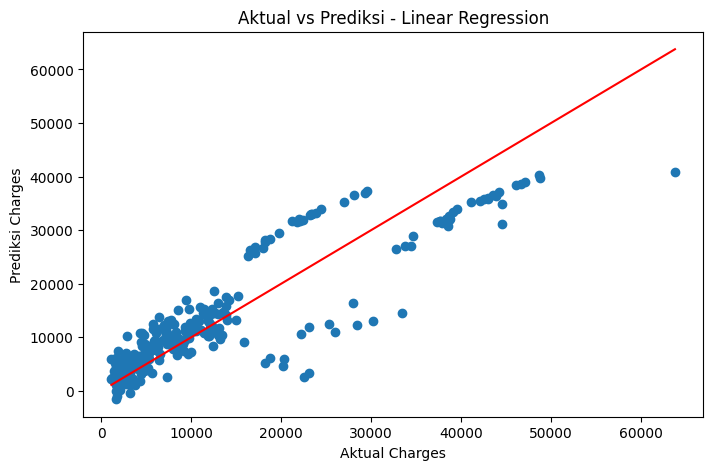

In [46]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_prediksi_linear)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Aktual Charges")
plt.ylabel("Prediksi Charges")
plt.title("Aktual vs Prediksi - Linear Regression")

plt.show()

Langkah 11: Model SVR

In [73]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

svr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))
])

svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)

svr_model.fit(X_train, y_train)
y_prediksi_svr = svr_model.predict(X_test)

Langkah 12: Evaluasi SVR

In [69]:
r2_svr = r2_score(y_test, y_prediksi_svr)
mse_svr = mean_squared_error(y_test, y_prediksi_svr)
mae_svr = mean_absolute_error(y_test, y_prediksi_svr)

print("Model SVR")
print("R-squared :", r2_svr)
print("MSE       :", mse_svr)
print("MAE       :", mae_svr)

Model SVR
R-squared : 0.8301994770198078
MSE       : 26361315.799314566
MAE       : 2894.134780279511


Langkah 13: Visualisasi hasil SVR

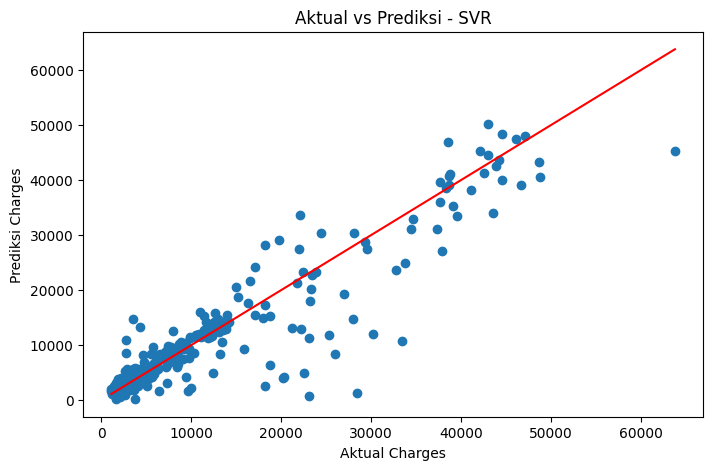

In [71]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_prediksi_svr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r"
)

plt.xlabel("Aktual Charges")
plt.ylabel("Prediksi Charges")
plt.title("Aktual vs Prediksi - SVR")

plt.show()

Analisis

Pada dataset, variabel 'age', 'sex', 'bmi', 'children', 'smoker', dan 'region' digunakan sebagai variabel yang memengaruhi biaya medis. Sementara itu, 'charges' digunakan sebagai variabel target, yaitu biaya medis yang ingin diprediksi.

Dataset dibagi menjadi dua bagian, yaitu 80% untuk data latih dan 20% untuk data uji. Variabel kategori seperti 'sex', 'smoker', dan 'region' diubah menjadi bentuk angka menggunakan One Hot Encoding. Sementara itu, variabel numerik dilakukan penskalaan menggunakan StandardScaler agar memiliki skala yang lebih seimbang.

Selanjutnya, dibuat dua model untuk memprediksi biaya medis, yaitu Multiple Linear Regression dan Support Vector Regression (SVR). Kedua model kemudian diuji menggunakan tiga ukuran evaluasi, yaitu R-squared, MSE, dan MAE.

R-squared digunakan untuk melihat seberapa baik model dapat menjelaskan variasi biaya medis. Sedangkan MSE dan MAE digunakan untuk mengetahui seberapa besar kesalahan prediksi yang dihasilkan model. Semakin tinggi nilai R-squared dan semakin rendah nilai MSE serta MAE, berarti hasil prediksi model semakin baik pada data uji.

Selain itu, dilakukan hyperparameter tuning pada model SVR menggunakan GridSearchCV. Proses ini bertujuan untuk mencari kombinasi parameter SVR yang menghasilkan performa model yang lebih baik.

Setelah proses pengujian selesai, hasil dari Multiple Linear Regression dan SVR dibandingkan berdasarkan nilai R-squared, MSE, dan MAE pada data uji.
